# Hand-Written Number Classifier

### written by: [Jehwan Kim](github.com/kreimben)

In [1]:
import matplotlib.pyplot as plt
import torch
from torchvision import datasets
from torchvision import transforms

%matplotlib inline

In [2]:
download_dir = './data'

train_data = datasets.MNIST(
    root=download_dir,
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

valid_data = datasets.MNIST(
    root=download_dir,
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

test_data = datasets.MNIST(
    root=download_dir,
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

In [3]:
len(train_data), len(valid_data), len(test_data)

(60000, 10000, 10000)

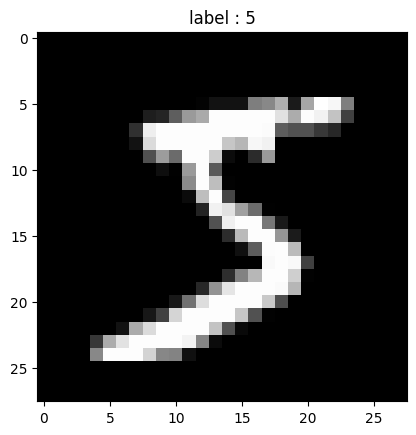

In [4]:
# Sometimes, plot doesn't work cuz I included normaliser and auto augment function.
image, label = train_data[0]
plt.imshow(image.squeeze().numpy(), cmap='gray')
plt.title(f'label : {label}')
plt.show()

In [5]:
# I already ready for dataloader in the lightning module.
# So delete the class.
del train_data, valid_data, test_data, image, label

### Training with LearningRateFinder.

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Users/kreimben/Repository/MNISTClassifier/venv/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:75: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
Missing logger folder: /Users/kreimben/Repository/MNISTClassifier/lightning_logs
/Users/kreimben/Repository/MNISTClassifier/venv/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:436: Consider setting `persistent_workers=True` in 'train_dataloader' to sp

Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=100` reached.
Learning rate set to 0.0003019951720402019
Restoring states from the checkpoint path at /Users/kreimben/Repository/MNISTClassifier/.lr_find_79aa34a5-de34-4952-b2a7-59bd0347d91a.ckpt
Restored all states from the checkpoint at /Users/kreimben/Repository/MNISTClassifier/.lr_find_79aa34a5-de34-4952-b2a7-59bd0347d91a.ckpt


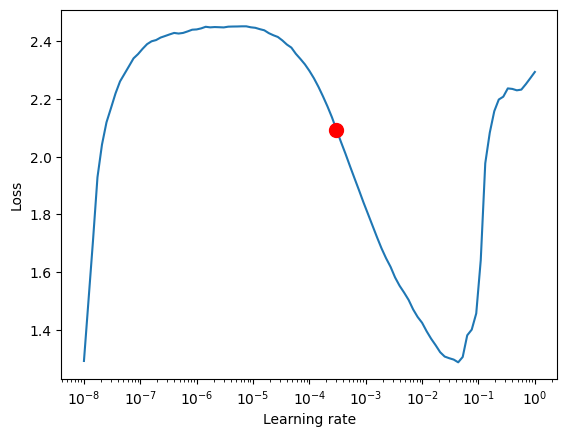

In [6]:
from lightning.pytorch.callbacks import EarlyStopping
from src.module import ResNet, ResidualBlock
import lightning as L
from lightning.pytorch.tuner import Tuner

trainer = L.Trainer(max_epochs=20, callbacks=[EarlyStopping(monitor="val_loss")])
tuner = Tuner(trainer)
model = ResNet(block=ResidualBlock, layers=[2, 2, 2, 2], grayscale=True, batch_size=128)

lr_finder = tuner.lr_find(model)

lr_finder.plot(suggest=True)

new_lr = lr_finder.suggestion()

model.hparams.learning_rate = new_lr

In [7]:
trainer.fit(model)


   | Name    | Type             | Params
----------------------------------------------
0  | loss    | CrossEntropyLoss | 0     
1  | conv1   | Conv2d           | 3.1 K 
2  | bn1     | BatchNorm2d      | 128   
3  | relu    | ReLU             | 0     
4  | maxpool | MaxPool2d        | 0     
5  | layer1  | Sequential       | 147 K 
6  | layer2  | Sequential       | 525 K 
7  | layer3  | Sequential       | 2.1 M 
8  | layer4  | Sequential       | 8.4 M 
9  | avgpool | AvgPool2d        | 0     
10 | fc      | Linear           | 5.1 K 
----------------------------------------------
11.2 M    Trainable params
0         Non-trainable params
11.2 M    Total params
44.701    Total estimated model params size (MB)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [8]:
trainer.test(model)

/Users/kreimben/Repository/MNISTClassifier/venv/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:436: Consider setting `persistent_workers=True` in 'test_dataloader' to speed up the dataloader worker initialization.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.9929999709129333
        test_loss          0.027075156569480896
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.027075156569480896, 'test_acc': 0.9929999709129333}]

### Save the model

In [9]:
# Convert to TorchScript
scripted_model = torch.jit.script(model)
# Save the scripted model
torch.jit.save(scripted_model, 'scripted_model.pt')